In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import plot_tree

In [2]:
A_Data = pd.read_csv("CancerData.csv")

systemic_features = [
    "Fatigue",
    "Weight Loss",
    "Swallowing Difficulty",
    "Clubbing of Finger Nails",
    "Snoring"
]

A_Data = A_Data.drop_duplicates().copy()

X = A_Data[systemic_features]
Y = A_Data["Level"]

assert "Level" not in X.columns, "Target leakage: Level is inside X"

print("Dataset shape after removing exact duplicate rows:", A_Data.shape)
print("Input columns:")
print(list(X.columns))
print("\nSystemic symptoms used in the screening model:")
for feature in systemic_features:
    print("-", feature)

print("\nRisk level labels:")
print(sorted(Y.unique()))

display(A_Data[["Patient Id"] + systemic_features + ["Level"]].head())

Dataset shape after removing exact duplicate rows: (1000, 26)
Input columns:
['Fatigue', 'Weight Loss', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Snoring']

Systemic symptoms used in the screening model:
- Fatigue
- Weight Loss
- Swallowing Difficulty
- Clubbing of Finger Nails
- Snoring

Risk level labels:
['High', 'Low', 'Medium']


,Patient Id,Fatigue,Weight Loss,Swallowing Difficulty,Clubbing of Finger Nails,Snoring,Level
0,P1,3,4,3,1,4,Low
1,P10,1,3,6,2,2,Medium
2,P100,8,7,1,4,2,High
3,P1000,4,2,4,5,5,High
4,P101,3,2,4,2,3,High


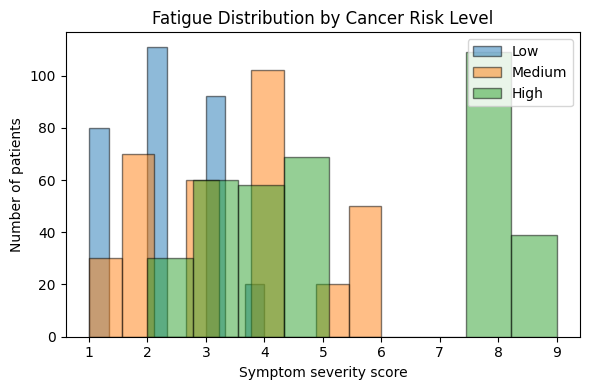

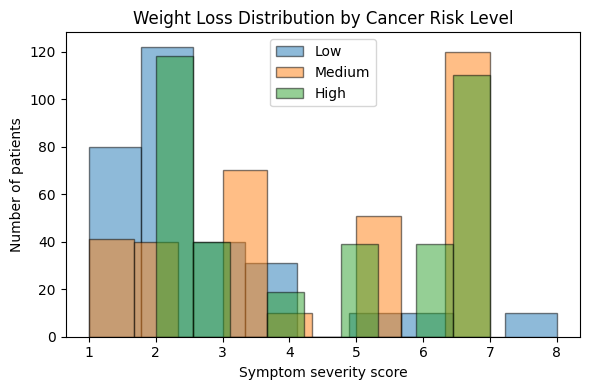

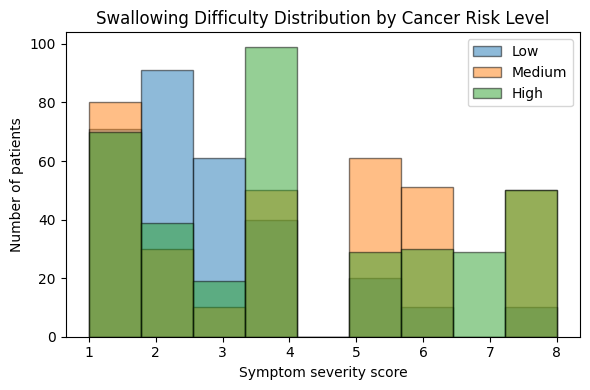

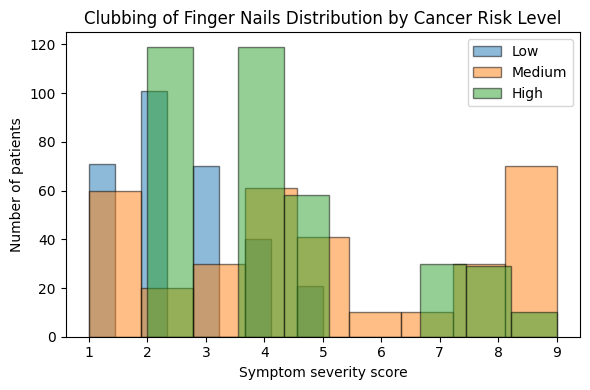

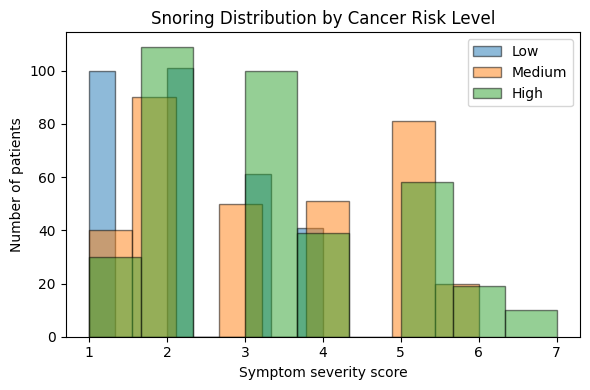

In [3]:
for feature in systemic_features:
    plt.figure(figsize=(6, 4))

    for level in ["Low", "Medium", "High"]:
        subset = A_Data[A_Data["Level"] == level]
        plt.hist(
            subset[feature],
            bins=9,
            alpha=0.5,
            label=level,
            edgecolor="black"
        )

    plt.title(f"{feature} Distribution by Cancer Risk Level")
    plt.xlabel("Symptom severity score")
    plt.ylabel("Number of patients")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [4]:
systemic_data = A_Data[systemic_features + ["Level"]].copy()

print("Missing values in selected data:")
display(systemic_data.isnull().sum())

print("Risk level counts:")
display(systemic_data["Level"].value_counts())

print("Mean systemic symptom score by risk level:")
symptom_means = systemic_data.groupby("Level")[systemic_features].mean().reindex(["Low", "Medium", "High"])
display(symptom_means.round(2))

Missing values in selected data:


Fatigue                     0
Weight Loss                 0
Swallowing Difficulty       0
Clubbing of Finger Nails    0
Snoring                     0
Level                       0
dtype: int64

Risk level counts:


Level
High      365
Medium    332
Low       303
Name: count, dtype: int64

Mean systemic symptom score by risk level:


,Fatigue,Weight Loss,Swallowing Difficulty,Clubbing of Finger Nails,Snoring
Level,,,,,
Low,2.17,2.50,2.76,2.47,2.14
Medium,3.49,4.42,4.16,4.94,3.31
High,5.59,4.47,4.19,4.21,3.23


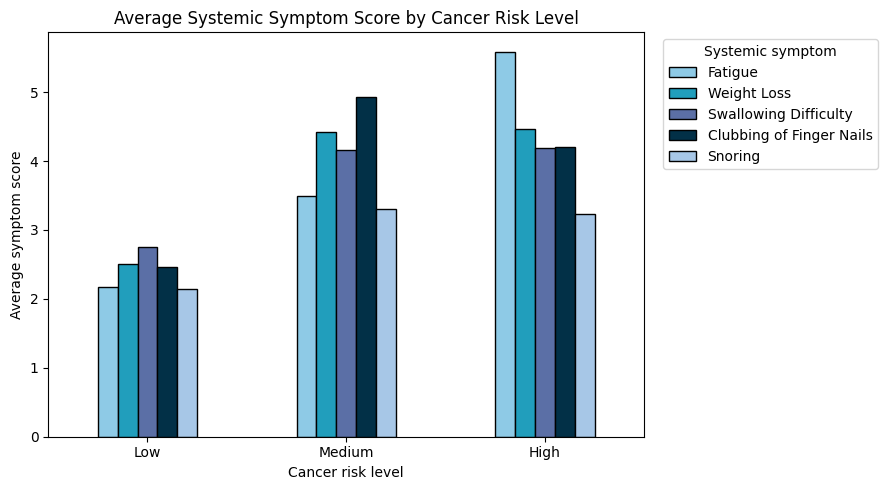

In [5]:
symptom_colours = ["#8ECAE6", "#219EBC", "#5B6FA6", "#023047", "#A7C7E7"]

ax = symptom_means.plot(
    kind="bar",
    figsize=(9, 5),
    edgecolor="black",
    color=symptom_colours
)

ax.set_title("Average Systemic Symptom Score by Cancer Risk Level")
ax.set_xlabel("Cancer risk level")
ax.set_ylabel("Average symptom score")
plt.xticks(rotation=0)
plt.legend(title="Systemic symptom", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [6]:
X_train, X_secondary, Y_train, Y_secondary = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=0,
    stratify=Y
)

X_validation, X_test, Y_validation, Y_test = train_test_split(
    X_secondary,
    Y_secondary,
    test_size=0.5,
    random_state=0,
    stratify=Y_secondary
)

split_summary = pd.DataFrame({
    "Split": ["Training", "Validation", "Test"],
    "Rows": [len(X_train), len(X_validation), len(X_test)]
})

display(split_summary)

print("Training class counts:")
display(Y_train.value_counts())

print("Validation class counts:")
display(Y_validation.value_counts())

print("Test class counts:")
display(Y_test.value_counts())

,Split,Rows
0,Training,800
1,Validation,100
2,Test,100


Training class counts:


Level
High      292
Medium    266
Low       242
Name: count, dtype: int64

Validation class counts:


Level
High      36
Medium    33
Low       31
Name: count, dtype: int64

Test class counts:


Level
High      37
Medium    33
Low       30
Name: count, dtype: int64

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, Y_train)

baseline_validation_pred = baseline_model.predict(X_validation)

baseline_cv_scores = cross_val_score(
    baseline_model,
    X_train,
    Y_train,
    cv=cv,
    scoring="recall_macro"
)

baseline_results = pd.DataFrame([{
    "Model": "Most Frequent Baseline",
    "Validation Accuracy": accuracy_score(Y_validation, baseline_validation_pred),
    "Validation Balanced Accuracy": balanced_accuracy_score(Y_validation, baseline_validation_pred),
    "Validation Macro Recall": recall_score(
        Y_validation,
        baseline_validation_pred,
        average="macro",
        zero_division=0
    ),
    "Cross-Validation Macro Recall": baseline_cv_scores.mean()
}]).round(3)

display(baseline_results)

def get_class_recall(y_true, y_pred, class_label="High"):
    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )
    if class_label in report:
        return report[class_label]["recall"]
    return np.nan

def evaluate_random_forest(params):
    model = RandomForestClassifier(
        **params,
        random_state=0,
        class_weight="balanced"
    )

    model.fit(X_train, Y_train)

    train_pred = model.predict(X_train)
    validation_pred = model.predict(X_validation)

    report = classification_report(
        Y_validation,
        validation_pred,
        output_dict=True,
        zero_division=0
    )

    return {
        "Training Accuracy": accuracy_score(Y_train, train_pred),
        "Validation Accuracy": accuracy_score(Y_validation, validation_pred),
        "Validation Balanced Accuracy": balanced_accuracy_score(Y_validation, validation_pred),
        "Validation Macro Recall": recall_score(
            Y_validation,
            validation_pred,
            average="macro",
            zero_division=0
        ),
        "Validation Macro F1": f1_score(
            Y_validation,
            validation_pred,
            average="macro",
            zero_division=0
        ),
        "Validation High-Risk Recall": report["High"]["recall"] if "High" in report else np.nan,
        "Train-Val Gap": accuracy_score(Y_train, train_pred) - accuracy_score(Y_validation, validation_pred)
    }

,Model,Validation Accuracy,Validation Balanced Accuracy,Validation Macro Recall,Cross-Validation Macro Recall
0,Most Frequent Baseline,0.36,0.333,0.333,0.333


In [8]:
base_params = {
    "n_estimators": 30,
    "max_depth": 1,
    "min_samples_split": 2,
    "min_impurity_decrease": 0.0
}

,max_depth,Training Accuracy,Validation Accuracy,Validation Balanced Accuracy,Validation Macro Recall,Validation Macro F1,Validation High-Risk Recall,Train-Val Gap
0,1,0.619,0.59,0.600,0.600,0.565,0.528,0.029
1,2,0.780,0.75,0.763,0.763,0.739,0.472,0.030
2,3,0.856,0.79,0.799,0.799,0.788,0.639,0.066
3,4,0.941,0.92,0.919,0.919,0.916,1.000,0.021
4,5,0.950,0.95,0.949,0.949,0.948,1.000,0.000
5,6,1.000,1.00,1.000,1.000,1.000,1.000,0.000
6,7,1.000,1.00,1.000,1.000,1.000,1.000,0.000
7,8,1.000,1.00,1.000,1.000,1.000,1.000,0.000
8,9,1.000,1.00,1.000,1.000,1.000,1.000,0.000
9,10,1.000,1.00,1.000,1.000,1.000,1.000,0.000


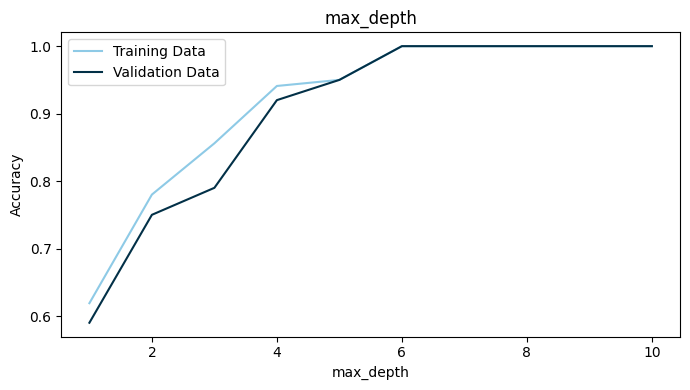

Selected max_depth: 6.0
Updated parameters:
{'n_estimators': 30, 'max_depth': 6, 'min_samples_split': 2, 'min_impurity_decrease': 0.0}


In [9]:
max_depth_results = []

for max_depth in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    params = base_params.copy()
    params["max_depth"] = max_depth

    scores = evaluate_random_forest(params)

    max_depth_results.append({
        "max_depth": max_depth,
        **scores
    })

max_depth_results = pd.DataFrame(max_depth_results).round(3)
display(max_depth_results)

plt.figure(figsize=(7, 4))
plt.plot(
    max_depth_results["max_depth"],
    max_depth_results["Training Accuracy"],
    label="Training Data",
    color="#8ECAE6"
)
plt.plot(
    max_depth_results["max_depth"],
    max_depth_results["Validation Accuracy"],
    label="Validation Data",
    color="#023047"
)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("max_depth")
plt.legend()
plt.tight_layout()
plt.show()

best_score = max_depth_results["Validation Balanced Accuracy"].max()

candidates = max_depth_results[
    max_depth_results["Validation Balanced Accuracy"] >= best_score - 0.02
].copy()

best_max_depth = candidates.sort_values("max_depth").iloc[0]["max_depth"]

print("Selected max_depth:", best_max_depth)

base_params["max_depth"] = int(best_max_depth)
print("Updated parameters:")
print(base_params)

,min_samples_split,Training Accuracy,Validation Accuracy,Validation Balanced Accuracy,Validation Macro Recall,Validation Macro F1,Validation High-Risk Recall,Train-Val Gap
0,2,1.00,1.00,1.000,1.000,1.000,1.0,0.0
1,5,1.00,1.00,1.000,1.000,1.000,1.0,0.0
2,10,0.99,0.99,0.990,0.990,0.990,1.0,0.0
3,20,0.99,0.99,0.990,0.990,0.990,1.0,0.0
4,30,0.98,0.98,0.980,0.980,0.979,1.0,0.0
5,50,0.95,0.95,0.949,0.949,0.948,1.0,0.0


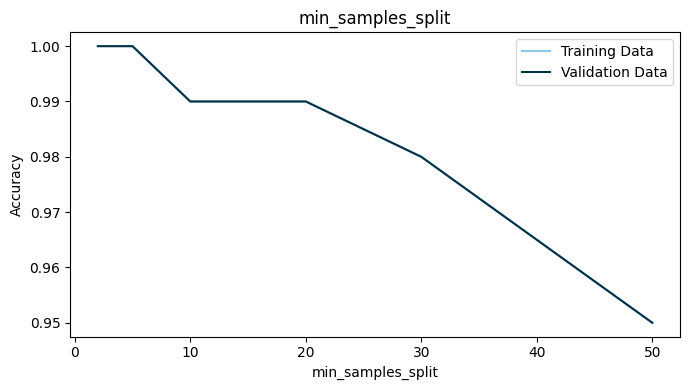

Selected min_samples_split: 30.0
Updated parameters:
{'n_estimators': 30, 'max_depth': 6, 'min_samples_split': 30, 'min_impurity_decrease': 0.0}


In [10]:
min_samples_split_results = []

for min_samples_split in [2, 5, 10, 20, 30, 50]:
    params = base_params.copy()
    params["min_samples_split"] = min_samples_split

    scores = evaluate_random_forest(params)

    min_samples_split_results.append({
        "min_samples_split": min_samples_split,
        **scores
    })

min_samples_split_results = pd.DataFrame(min_samples_split_results).round(3)
display(min_samples_split_results)

plt.figure(figsize=(7, 4))
plt.plot(
    min_samples_split_results["min_samples_split"],
    min_samples_split_results["Training Accuracy"],
    label="Training Data",
    color="#8ECAE6"
)
plt.plot(
    min_samples_split_results["min_samples_split"],
    min_samples_split_results["Validation Accuracy"],
    label="Validation Data",
    color="#023047"
)
plt.xlabel("min_samples_split")
plt.ylabel("Accuracy")
plt.title("min_samples_split")
plt.legend()
plt.tight_layout()
plt.show()

best_score = min_samples_split_results["Validation Balanced Accuracy"].max()

candidates = min_samples_split_results[
    min_samples_split_results["Validation Balanced Accuracy"] >= best_score - 0.02
].copy()

best_min_samples_split = candidates.sort_values(
    "min_samples_split",
    ascending=False
).iloc[0]["min_samples_split"]

print("Selected min_samples_split:", best_min_samples_split)

base_params["min_samples_split"] = int(best_min_samples_split)
print("Updated parameters:")
print(base_params)

,min_impurity_decrease,Training Accuracy,Validation Accuracy,Validation Balanced Accuracy,Validation Macro Recall,Validation Macro F1,Validation High-Risk Recall,Train-Val Gap
0,0.000,0.980,0.98,0.980,0.980,0.979,1.000,0.000
1,0.001,0.980,0.98,0.980,0.980,0.979,1.000,0.000
2,0.005,0.980,0.98,0.980,0.980,0.979,1.000,0.000
3,0.010,0.950,0.95,0.949,0.949,0.948,1.000,0.000
4,0.020,0.920,0.91,0.912,0.912,0.909,0.889,0.010
5,0.050,0.752,0.71,0.723,0.723,0.699,0.444,0.042


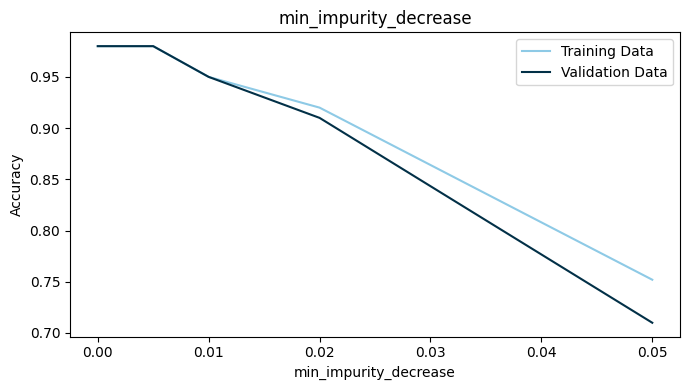

Selected min_impurity_decrease: 0.005
Updated parameters:
{'n_estimators': 30, 'max_depth': 6, 'min_samples_split': 30, 'min_impurity_decrease': 0.005}


In [11]:
min_impurity_results = []

for min_impurity_decrease in [0.0, 0.001, 0.005, 0.01, 0.02, 0.05]:
    params = base_params.copy()
    params["min_impurity_decrease"] = min_impurity_decrease

    scores = evaluate_random_forest(params)

    min_impurity_results.append({
        "min_impurity_decrease": min_impurity_decrease,
        **scores
    })

min_impurity_results = pd.DataFrame(min_impurity_results).round(3)
display(min_impurity_results)

plt.figure(figsize=(7, 4))
plt.plot(
    min_impurity_results["min_impurity_decrease"],
    min_impurity_results["Training Accuracy"],
    label="Training Data",
    color="#8ECAE6"
)
plt.plot(
    min_impurity_results["min_impurity_decrease"],
    min_impurity_results["Validation Accuracy"],
    label="Validation Data",
    color="#023047"
)
plt.xlabel("min_impurity_decrease")
plt.ylabel("Accuracy")
plt.title("min_impurity_decrease")
plt.legend()
plt.tight_layout()
plt.show()

best_score = min_impurity_results["Validation Balanced Accuracy"].max()

candidates = min_impurity_results[
    min_impurity_results["Validation Balanced Accuracy"] >= best_score - 0.02
].copy()

best_min_impurity_decrease = candidates.sort_values(
    "min_impurity_decrease",
    ascending=False
).iloc[0]["min_impurity_decrease"]

print("Selected min_impurity_decrease:", best_min_impurity_decrease)

base_params["min_impurity_decrease"] = float(best_min_impurity_decrease)
print("Updated parameters:")
print(base_params)

,n_estimators,Training Accuracy,Validation Accuracy,Validation Balanced Accuracy,Validation Macro Recall,Validation Macro F1,Validation High-Risk Recall,Train-Val Gap
0,50,0.98,0.98,0.98,0.98,0.979,1.0,0.0
1,100,0.98,0.98,0.98,0.98,0.979,1.0,0.0
2,150,0.98,0.98,0.98,0.98,0.979,1.0,0.0
3,200,0.98,0.98,0.98,0.98,0.979,1.0,0.0
4,300,0.98,0.98,0.98,0.98,0.979,1.0,0.0
5,400,0.98,0.98,0.98,0.98,0.979,1.0,0.0
6,500,0.98,0.98,0.98,0.98,0.979,1.0,0.0


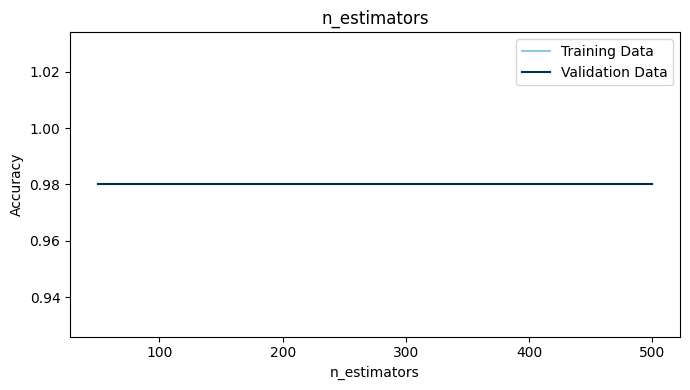

Selected n_estimators: 50.0
Final selected parameters:
{'n_estimators': 50, 'max_depth': 6, 'min_samples_split': 30, 'min_impurity_decrease': 0.005}


In [12]:
n_estimators_results = []

for n_estimators in [50, 100, 150, 200, 300, 400, 500]:
    params = base_params.copy()
    params["n_estimators"] = n_estimators

    scores = evaluate_random_forest(params)

    n_estimators_results.append({
        "n_estimators": n_estimators,
        **scores
    })

n_estimators_results = pd.DataFrame(n_estimators_results).round(3)
display(n_estimators_results)

plt.figure(figsize=(7, 4))
plt.plot(
    n_estimators_results["n_estimators"],
    n_estimators_results["Training Accuracy"],
    label="Training Data",
    color="#8ECAE6"
)
plt.plot(
    n_estimators_results["n_estimators"],
    n_estimators_results["Validation Accuracy"],
    label="Validation Data",
    color="#023047"
)
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("n_estimators")
plt.legend()
plt.tight_layout()
plt.show()

best_score = n_estimators_results["Validation Balanced Accuracy"].max()

candidates = n_estimators_results[
    n_estimators_results["Validation Balanced Accuracy"] >= best_score - 0.02
].copy()

best_n_estimators = candidates.sort_values("n_estimators").iloc[0]["n_estimators"]

print("Selected n_estimators:", best_n_estimators)

base_params["n_estimators"] = int(best_n_estimators)
print("Final selected parameters:")
print(base_params)

In [13]:
final_model = RandomForestClassifier(
    **base_params,
    random_state=0,
    class_weight="balanced"
)

final_model.fit(X_train, Y_train)

random_forest = final_model

Y_train_pred = final_model.predict(X_train)
Y_validation_pred = final_model.predict(X_validation)
Y_test_pred = final_model.predict(X_test)

test_report = classification_report(
    Y_test,
    Y_test_pred,
    output_dict=True,
    zero_division=0
)

final_results = pd.DataFrame([{
    "n_estimators": base_params["n_estimators"],
    "max_depth": base_params["max_depth"],
    "min_samples_split": base_params["min_samples_split"],
    "min_impurity_decrease": base_params["min_impurity_decrease"],
    "Training Accuracy": accuracy_score(Y_train, Y_train_pred),
    "Validation Accuracy": accuracy_score(Y_validation, Y_validation_pred),
    "Test Accuracy": accuracy_score(Y_test, Y_test_pred),
    "Test Balanced Accuracy": balanced_accuracy_score(Y_test, Y_test_pred),
    "Test Macro Recall": recall_score(
        Y_test,
        Y_test_pred,
        average="macro",
        zero_division=0
    ),
    "Test Macro F1": f1_score(
        Y_test,
        Y_test_pred,
        average="macro",
        zero_division=0
    ),
    "Test High-Risk Recall": test_report["High"]["recall"] if "High" in test_report else np.nan
}]).round(3)

display(final_results)

,n_estimators,max_depth,min_samples_split,min_impurity_decrease,Training Accuracy,Validation Accuracy,Test Accuracy,Test Balanced Accuracy,Test Macro Recall,Test Macro F1,Test High-Risk Recall
0,50,6,30,0.005,0.98,0.98,0.98,0.98,0.98,0.979,1.0


In [14]:
dummy_model = DummyClassifier(strategy="most_frequent", random_state=0)
dummy_model.fit(X_train, Y_train)

base_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=1,
    min_samples_split=2,
    min_impurity_decrease=0.0,
    random_state=0,
    class_weight="balanced"
)
base_model.fit(X_train, Y_train)

tuned_model = final_model

models = {
    "Dummy Baseline": dummy_model,
    "Base Random Forest": base_model,
    "Tuned Random Forest": tuned_model
}

splits = {
    "Training": (X_train, Y_train),
    "Validation": (X_validation, Y_validation),
    "Test": (X_test, Y_test)
}

simple_results = []

for model_name, model in models.items():
    for split_name, (X_split, Y_split) in splits.items():
        Y_pred = model.predict(X_split)

        simple_results.append({
            "Model": model_name,
            "Split": split_name,
            "Accuracy": accuracy_score(Y_split, Y_pred),
            "Precision": precision_score(
                Y_split,
                Y_pred,
                average="macro",
                zero_division=0
            ),
            "Recall": recall_score(
                Y_split,
                Y_pred,
                average="macro",
                zero_division=0
            )
        })

simple_results = pd.DataFrame(simple_results).round(3)

display(simple_results)


,Model,Split,Accuracy,Precision,Recall
0,Dummy Baseline,Training,0.365,0.122,0.333
1,Dummy Baseline,Validation,0.360,0.120,0.333
2,Dummy Baseline,Test,0.370,0.123,0.333
3,Base Random Forest,Training,0.619,0.651,0.630
4,Base Random Forest,Validation,0.590,0.628,0.600
5,Base Random Forest,Test,0.650,0.713,0.663
6,Tuned Random Forest,Training,0.980,0.979,0.980
7,Tuned Random Forest,Validation,0.980,0.980,0.980
8,Tuned Random Forest,Test,0.980,0.979,0.980


In [15]:
class_distribution = pd.DataFrame({
    "Dataset": ["Full dataset", "Training set", "Validation set", "Test set"],
    "High": [
        int(Y.value_counts().reindex(["High", "Medium", "Low"])["High"]),
        int(Y_train.value_counts().reindex(["High", "Medium", "Low"])["High"]),
        int(Y_validation.value_counts().reindex(["High", "Medium", "Low"])["High"]),
        int(Y_test.value_counts().reindex(["High", "Medium", "Low"])["High"])
    ],
    "Medium": [
        int(Y.value_counts().reindex(["High", "Medium", "Low"])["Medium"]),
        int(Y_train.value_counts().reindex(["High", "Medium", "Low"])["Medium"]),
        int(Y_validation.value_counts().reindex(["High", "Medium", "Low"])["Medium"]),
        int(Y_test.value_counts().reindex(["High", "Medium", "Low"])["Medium"])
    ],
    "Low": [
        int(Y.value_counts().reindex(["High", "Medium", "Low"])["Low"]),
        int(Y_train.value_counts().reindex(["High", "Medium", "Low"])["Low"]),
        int(Y_validation.value_counts().reindex(["High", "Medium", "Low"])["Low"]),
        int(Y_test.value_counts().reindex(["High", "Medium", "Low"])["Low"])
    ],
    "Total": [len(Y), len(Y_train), len(Y_validation), len(Y_test)]
})

table_style = [
    {
        "selector": "caption",
        "props": [
            ("caption-side", "bottom"),
            ("font-weight", "bold"),
            ("font-size", "12px"),
            ("color", "#666666")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("background-color", "#023047"),
            ("color", "white"),
            ("font-weight", "bold"),
            ("text-align", "center"),
            ("border", "1px solid #D9D9D9")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center"),
            ("border", "1px solid #D9D9D9"),
            ("padding", "6px")
        ]
    }
]

display(
    class_distribution.style
    .hide(axis="index")
    .set_caption("Table X. Class distribution after stratified splitting")
    .set_table_styles(table_style)
)

feature_pattern_summary = pd.DataFrame({
    "Measure": [
        "Total rows",
        "Unique feature patterns",
        "Duplicate feature patterns"
    ],
    "Value": [
        X.shape[0],
        X.drop_duplicates().shape[0],
        X.duplicated().sum()
    ]
})

display(
    feature_pattern_summary.style
    .hide(axis="index")
    .set_caption("Table X. Feature pattern summary for the five selected systemic symptoms")
    .set_table_styles(table_style)
)


Dataset,High,Medium,Low,Total
Full dataset,365,332,303,1000
Training set,292,266,242,800
Validation set,36,33,31,100
Test set,37,33,30,100


Measure,Value
Total rows,1000
Unique feature patterns,49
Duplicate feature patterns,951


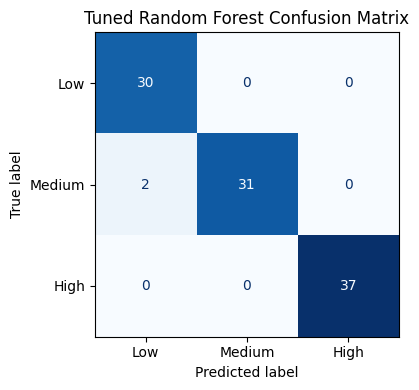

In [16]:
class_order = ["Low", "Medium", "High"]
cm = confusion_matrix(Y_test, Y_test_pred, labels=class_order)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order).plot(
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax
)
ax.set_title("Tuned Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

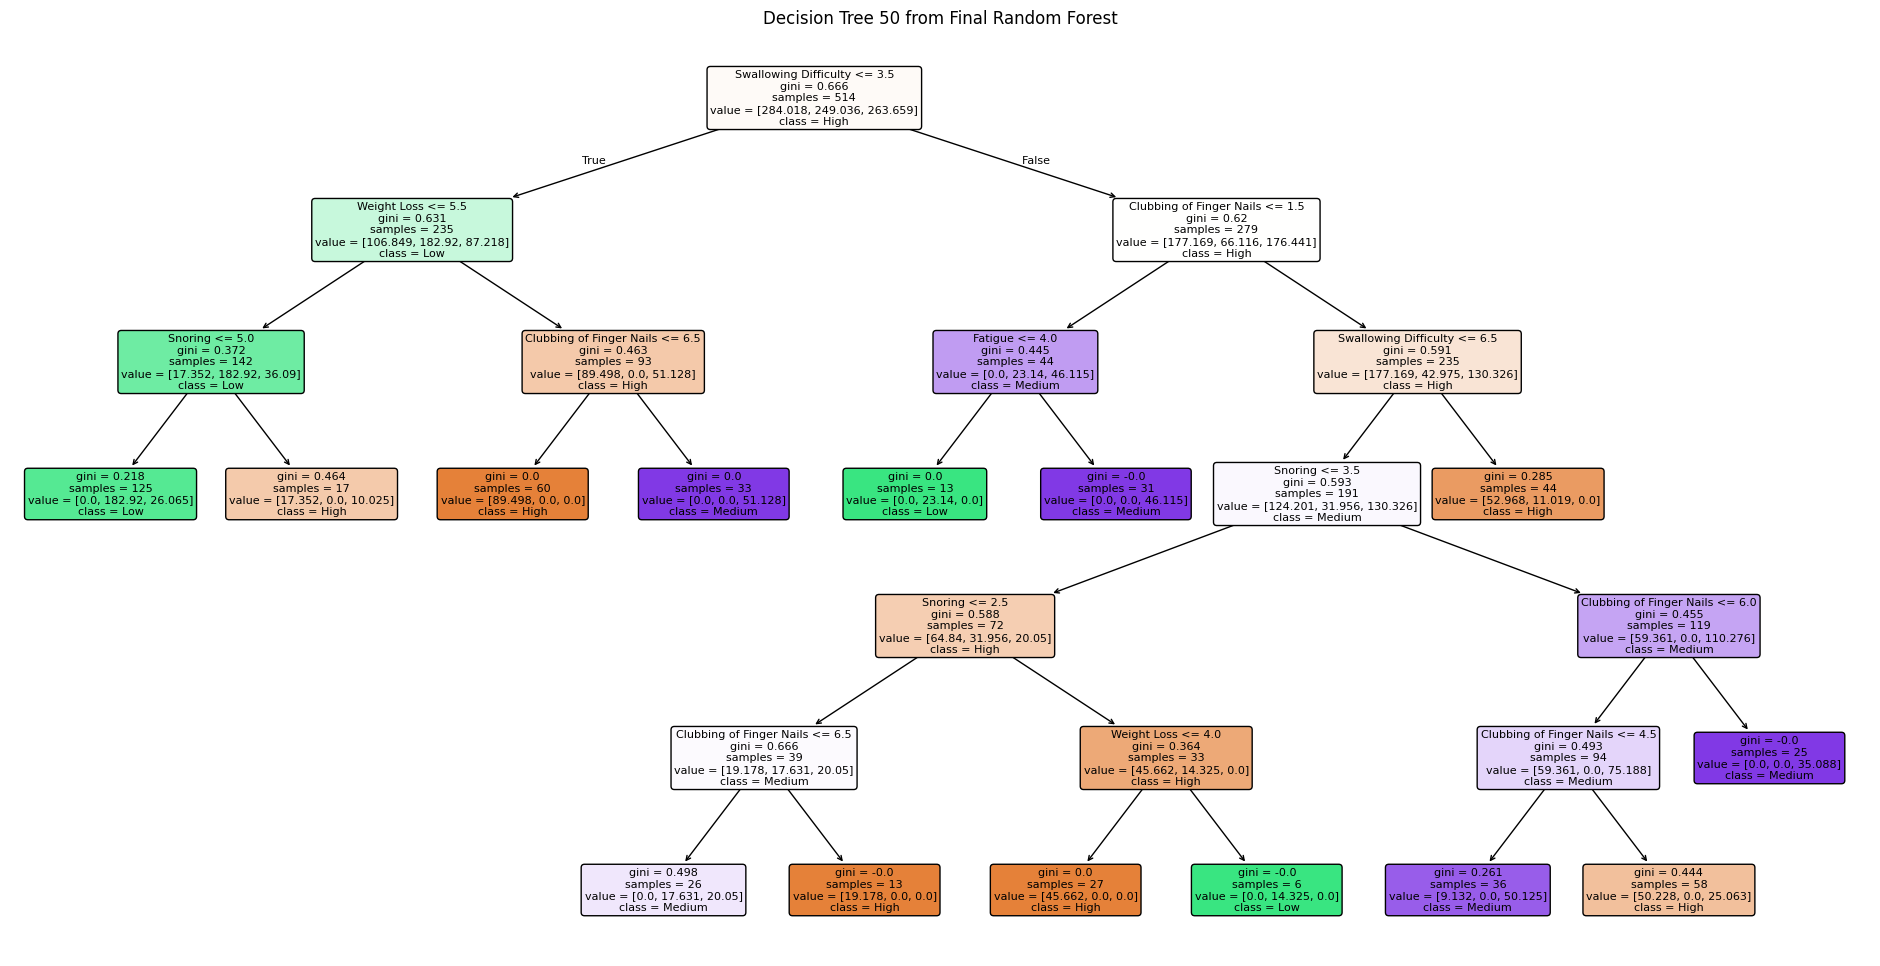

In [17]:
tree_number = 49

plt.figure(figsize=(24, 12))

plot_tree(
    final_model.estimators_[tree_number],
    feature_names=X_train.columns,
    class_names=[str(c) for c in final_model.classes_],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree 50 from Final Random Forest")
plt.savefig("decision_tree_50.png", dpi=300, bbox_inches="tight")
plt.show()

,Feature,Importance
0,Fatigue,0.303
3,Clubbing of Finger Nails,0.221
1,Weight Loss,0.165
2,Swallowing Difficulty,0.164
4,Snoring,0.146


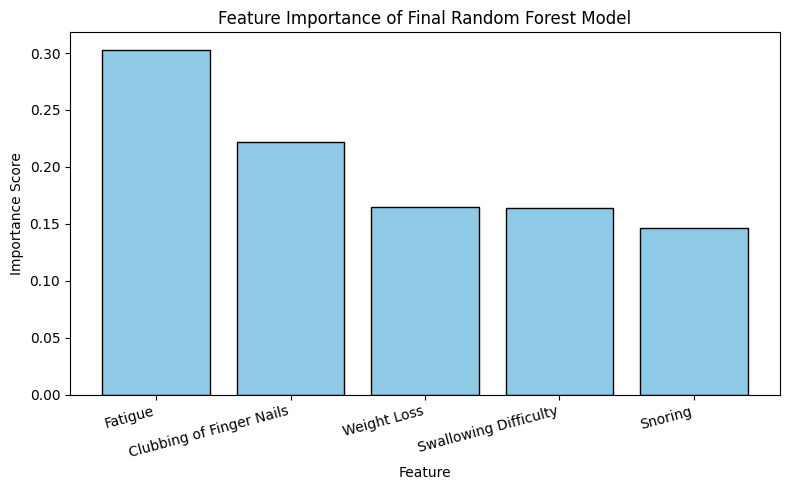

In [18]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.round(3))

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"],
     color="#8ECAE6",
     edgecolor="black"
)

plt.title("Feature Importance of Final Random Forest Model")
plt.xlabel("Feature")
plt.ylabel("Importance Score")

plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [19]:
permutation_result = permutation_importance(
    random_forest,
    X_test,
    Y_test,
    n_repeats=30,
    random_state=0,
    scoring="accuracy"
)

permutation_importance_table = pd.DataFrame({
    "Systemic Symptom": systemic_features,
    "Mean Accuracy Drop When Shuffled": permutation_result.importances_mean,
    "Standard Deviation": permutation_result.importances_std
})

permutation_importance_table = permutation_importance_table.sort_values(
    "Mean Accuracy Drop When Shuffled",
    ascending=False
).reset_index(drop=True)

permutation_importance_table["Mean Accuracy Drop When Shuffled"] = permutation_importance_table["Mean Accuracy Drop When Shuffled"].round(4)
permutation_importance_table["Standard Deviation"] = permutation_importance_table["Standard Deviation"].round(4)

display(permutation_importance_table)


,Systemic Symptom,Mean Accuracy Drop When Shuffled,Standard Deviation
0,Fatigue,0.3507,0.0399
1,Swallowing Difficulty,0.1963,0.0312
2,Clubbing of Finger Nails,0.1870,0.0222
3,Weight Loss,0.0993,0.0231
4,Snoring,0.0990,0.0180
